# Geometry generation

In this tutorial, we will show:

1. How to create the geometry for a simulation by Mixin in PorePy.
2. How to define fractures and a fracture network in a 2d domain.
2. How to visualize the mesh.

In [2]:
import porepy as pp
import numpy as np
from porepy.models.fluid_mass_balance import SinglePhaseFlow

from porepy.applications.md_grids.domains import nd_cube_domain


class ModifiedGeometry:
    def set_domain(self) -> None:
        """Defining a two-dimensional square domain with sidelength 2."""
        size = self.units.convert_units(2, "m")
        self._domain = nd_cube_domain(2, size)

    def set_fractures(self) -> None:
        """Setting a diagonal fracture"""
        frac_1_points = self.units.convert_units(
            np.array([[0.2, 1.8], [1.0, 1.0]]), "m"
        )
        frac_1 = pp.LineFracture(frac_1_points)
        self._fractures = [frac_1]

    def grid_type(self) -> str:
        """Choosing the grid type for our domain.

        As we have a diagonal fracture we cannot use a cartesian grid.
        Cartesian grid is the default grid type, and we therefore override this method to assign simplex instead.

        """
        return self.params.get("grid_type", "simplex")

    def meshing_arguments(self) -> dict:
        """Meshing arguments for md-grid creation.

        Here we determine the cell size.

        """
        cell_size = self.units.convert_units(0.25, "m")
        mesh_args: dict[str, float] = {"cell_size": cell_size}
        return mesh_args

Then, we combine the above class with an single phase flow model: 

In [3]:
class GeometryModel(
    ModifiedGeometry,
    SinglePhaseFlow):
    ...

Plot

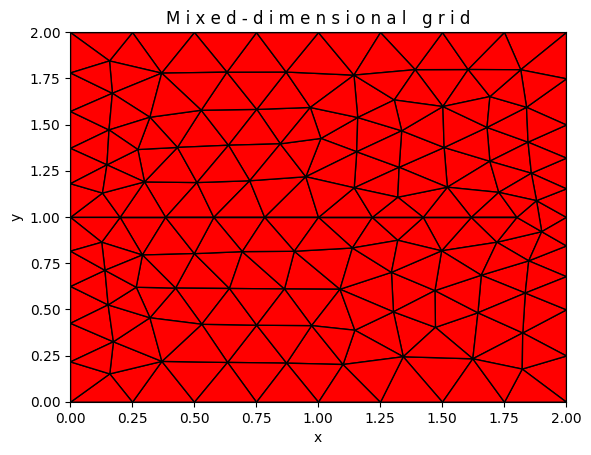

In [4]:
model_params = {
    "grid_type": "simplex",
}
model = GeometryModel(model_params)
model.prepare_simulation()
pp.plot_grid(model.mdg, figsize=(8,8), plot_2d=True)

Cartesian

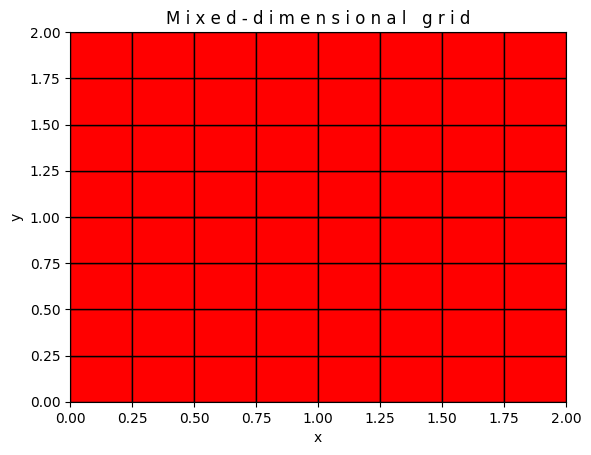

In [5]:
model_params = {
    "grid_type": "cartesian",
}
model = GeometryModel(model_params)
model.prepare_simulation()
pp.plot_grid(model.mdg, figsize=(8,8), plot_2d=True)